In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI # thư viện chính để sử dụng Google Generative AI
from dotenv import find_dotenv, load_dotenv # thư viện để load biến môi trường từ file .env
from langchain_core.prompts import (
    HumanMessagePromptTemplate,
    ChatPromptTemplate
) # phục vụ cho việc tạo prompt
from pydantic import BaseModel, Field # thư viện để định nghĩa kiểu dữ liệu
from langchain_core.output_parsers import PydanticOutputParser # thư viện để phân tích đầu ra từ mô hình
from typing import Optional # Giúp xử lí các kiểu dữ liệu tùy chọn, ví dụ Optional[str] có thể là str hoặc None
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pandas as pd
import getpass
import time
import json
import warnings
import concurrent.futures
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import random

In [2]:
#Bỏ qua cảnh báo FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# GIAI ĐOẠN 1: TẠO PROMPT VÀ ĐIỀU CHỈNH NỘI DUNG PHÙ HỢP, ÁP DỤNG CÁC KĨ THUẬT ONE-SHOT VÀ FEW-SHOT PROMPTING


In [3]:
#  NHÓM 1: THÔNG TIN CƠ BẢN 
class JobGeneralInfo(BaseModel):
    #Lấy tên công việc
    Job_Title: Optional[str] = Field(default = "",description="Lấy đầy đủ tên công việc, chính xác từng chữ trong yêu cầu tuyển dụng, chỉ lấy thông tin liên quan đến tên công việc, tuyệt đối không đưa các thông tin liên quan đến các nội dung sau vào mục job_title:" \
        "Số năm kinh nghiệm, " \
        "Mức lương hay thông tin về thưởng thêm, phụ cấp, " \
        "Ngoại ngữ yêu cầu ví dụ như tiếng Anh, tiếng Trung,... " \
        "Địa điểm, thành phố, quốc gia, tuyển dụng ví dụ như Hồ Chí Minh,... " \
        "Thông tin về ngày nghỉ, ngày làm việc trong tuần (ví dụ Nghỉ Thứ 7 - Chủ Nhật) (Sử dụng thông tin ngày nghỉ này để điền cho các trường liên quan đến việc có đi làm thứ 7 hay Chủ Nhật không), " \
        "Ngoài các thông tin trên, hãy giữ lại đầy đủ tên công việc và thông tin liên quan đến vị trí công việc đó, ví dụ: Senior BA (Gaming/Social/Metaverse) thì vẫn giữ là Senior BA (Gaming/Social/Metaverse)" \
        "Sau đó, viết hoa chữ cái đầu tiếng Việt, tiếng Anh thì viết hoa tên công việc, ví dụ: lập trình viên backend Developer (Golang Từ 2 Năm Kinh Nghiệm, 20 - 25 Triệu/Tháng, Tiếng Anh, Hồ Chí Minh, Nghỉ Thứ 7 - Chủ Nhật, Thu Nhập Hấp Dẫn) chuyển thành duy nhất thông tin liên quan đến nghề nghiệp và chuyên môn là: Lập trình viên Backend Developer")

    # Lấy tất cả các tên, vị trí chuyên môn được yêu cầu
    Roles: Optional[list] = Field(default = [""],description="Dựa vào tags_role để lấy chính xác tất cả tên, vị trí hay lĩnh vực chuyên môn được yêu cầu và đề cập trong thông tin, ví dụ: Backend Developer, Frontend Developer, DevOps Engineer, Data Scientist, AI Engineer, Mobile Developer, Game Developer, QA Engineer, Security Specialist, Cloud Engineer, Fullstack Developer, System Administrator, Database Administrator, Network Engineer, Software Architect, Technical Lead, Project Manager, Business Analyst, UI/UX Designer, Product Manager, Scrum Master, IT Support Specialist, Việc làm IT, và các vị trí hay lĩnh vực chuyên môn khác. Yêu cầu không được thêm bớt nội dung không liên quan, hãy trả về chính xác nội dung vị trí, lĩnh vực chuyên môn được đề cập đồng thời viết hoa toàn bộ kết quả trả về. Nếu không có thông tin về các vị trí chuyên môn trong yêu cầu tuyển dụng thì trả về giá trị là danh sách rỗng")
    
    #Lấy số lượng tuyển dụng
    Recruitment_Count : Optional[int] = Field(default = 1, description="Lấy chính xác số lượng tuyển dụng từ 'quantity', ví dụ 1,2, nếu không có thông tin thì trả về giá trị là 1")
    
    #Lấy tên tỉnh thành tuyển dụng
    Province: Optional[list] = Field(default = [""],description="Lấy chính xác tất cả tên tỉnh thành được đề cập trong địa điểm tuyển dụng là 'tags_location', kết quả trả về dưới dạng in hoa, ví dụ: HÀ NỘI, THÀNH PHỐ HỒ CHÍ MINH, hoặc nếu không có tỉnh thành cụ thể mà chỉ ghi là 'Nước ngoài' thì hãy trả kết quả về là 'NƯỚC NGOÀI'. Trả về giá trị là danh sách rỗng nếu không có thông tin về tỉnh thành trong yêu cầu tuyển dụng")
    
    # Lấy địa chỉ tên tỉnh thành của công ty
    Company_Location: Optional[list] = Field(default = [""],description="Dựa vào thông tin trong 'company_address' để lấy chính xác tất cả tên tỉnh thành nơi công ty đóng trụ sở, kết quả trả về dưới dạng danh sách in hoa, ví dụ: HÀ NỘI, HỒ CHÍ MINH, ĐÀ NẴNG. Nếu như không có tên tỉnh thành trong 'company_address' thì hãy dựa vào 'province' để lấy tên tỉnh thành nơi công ty đóng trụ sở. Chú ý định dạng trả về chỉ lấy tên của tỉnh thành, ví dụ Thành phố Hồ Chí Minh, Thành phố Đà Nẵng thì chỉ trả về là HỒ CHÍ MINH, ĐÀ NẴNG chứ không lấy thông tin phụ. Trả về giá trị là rỗng nếu không có thông tin về tỉnh thành trong 'company_address' và 'province'.")
    
    # Lấy số lượng nhân viên tối thiểu hiện có của công ty
    Current_Employee_Min : Optional[int] = Field(default = None, description="Dựa vào thông tin trong 'company_scale' để lấy chính xác số lượng nhân viên tối thiểu hiện có của công ty, ví dụ: nếu ghi là 50-100 nhân viên thì trả về giá trị là 50. Ví dụ nếu thông tin là 1000+ thì trả về giá trị là 1000. Nếu không có thông tin về số lượng nhân viên hiện có thì trả về giá trị là None")
    
    # Lấy số lượng nhân viên tối đa hiện có của công ty
    Current_Employee_Max : Optional[int] = Field(default = None, description="Dựa vào thông tin trong 'company_scale' để lấy chính xác số lượng nhân viên tối đa hiện có của công ty, ví dụ: nếu ghi là 50-100 nhân viên thì trả về giá trị là 100. Ví dụ nếu thông tin là 1000+ thì trả về giá trị là None. Nếu không có thông tin về số lượng nhân viên hiện có thì trả về giá trị là None") 
    
    #Lấy thông tin ngoại ngữ làm việc
    Language: Optional[list] = Field(default = [""], description="Dựa vào địa điểm nơi làm việc, xác định ngôn ngữ đầu tiên. Sau đó trích ra thêm các ngoại ngữ yêu cầu dựa vào 'job_description' và 'tags_skill' nếu nhà tuyển dụng có yêu cầu, bỏ các thông tin phụ về cấp độ, chú ý không dựa vào 'job_benefits' để lấy thông tin ngoại ngữ yêu cầu vì đây là nội dung về phúc lợi chứ không phải yêu cầu ngoại ngữ trong tuyển dụng. Trả về kết quả dưới dạng chữ in hoa ví dụ: TIẾNG VIỆT, TIẾNG ANH")
    

#  NHÓM 2: YÊU CẦU KỸ THUẬT (Cần độ chính xác cao về thuật ngữ) 
class JobTechnicalInfo(BaseModel):
    #Lấy tất cả Tech Stack
    Tech_Stack: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả các Tech Stack, tên các thuật ngữ chuyên môn được yêu cầu (Mobile, Web, Docker,Database Management System,...) và các công nghệ, phương pháp lập trình OOP, skills, tools, môn học như toán (Đại Số, Xác Suất Thống Kê), hệ quản trị cơ sở dữ liệu như MySQL, SQL Sever,PostgreSQL, vân vân... (nếu có), không điền ngôn ngữ truy vấn SQL vào mục này vì nó thuộc mục 'Programming_Language', viết hoa toàn bộ chữ cái, đề nghị quy chuẩn hết về 1 tên gọi (Không được trả về 1 câu) chính thức của công nghệ và tools được tìm thấy, đồng thời kết quả trả về dưới dạng chữ in hoa toàn bộ. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các tech stack và skill khác:" \ 
    "AWS": ["AWS", "AMAZON WEB SERVICES", "AWS CLOUD", "AMAZON CLOUD"], \
    "SQL SERVER": ["SQL SERVER", "MSSQL", "MS SQL", "MICROSOFT SQL SERVER", "SQLSERVER", "SQL SEVER", "MS SQL SERVER", "MSSQLSERVER", "MS-SQL SERVER", "MS SQL DATABASE"],
    "POSTGRESQL : Postgre Sql" 
    "MYSQL": ["My SQL", "MySQL"], \
    "CI/CD": ["CI/CD", "CICD", "CI CD", "CONTINUOUS INTEGRATION", "CONTINUOUS DELIVERY", "CONTINUOUS DEPLOYMENT", "CI", "CI-CD", "CI CD PIPELINES", "CI CD PIPELINE", "CI/CT", "DEVOPS CI/CD"], \
    "DOCKER": ["DOCKER", "DOCKER CONTAINERS", "DOCKER CONTAINERIZATION", "DOCKER SWARM", "DOCKER KUBERNETES", "CONTAINERIZATION WITH DOCKER", "DOCKER IMAGES", "DOCKER HUB"]
    """)
    #Lấy tất cả tên ngôn ngữ lập trình/truy vấn
    Programming_Language: Optional[list] = Field(default =[""],description=r"""Dựa vào 'job_description' và 'job_requirements' để lấy chính xác, nhất quán tên chính thức của tất cả tên ngôn ngữ lập trình,ví dụ thông tin có đề cập đến việc sử dụng Python, C++, Java thì trả về đúng tên ngôn ngữ lập trình là PYTHON, C++, JAVA, tương tự với các ngôn ngữ lập trình khác, viết hoa toàn bộ chữ cái. Yêu cầu khi bạn trích ra tên các ngôn ngữ lập trình thì hãy sử dụng tên nhất quán của các công nghệ, ngôn ngữ lập trình, thuật ngữ chuyên môn, nếu có nhiều tên gọi khác nhau thì hãy chọn 1 tên gọi chính thức nhất để sử dụng nhằm tạo độ nhất quán cho tên các công nghệ, tránh hiện tượng 1 ngôn ngữ lập trình được gọi và trả về kết quả là nhiều tên gọi khác nhau. Ví dụ, xem xét các dạng sau để thống nhất và trả về 1 key từ các biến thể là list các value, áp dụng tương tự cho các ngôn ngữ lập trình và truy vấn khác: 
    "Python" : "PYTHON"
    "Java Script" : "JAVASCRIPT"
    "JS" : "JAVASCRIPT"
    "Type Script" : "TYPESCRIPT"
    "JAVASCRIPT": ["JAVASCRIPT", "JS", "ES5", "ES6", "ES6+"],
    "SQL": ["SQL", "PL/SQL", "PLSQL", "T-SQL", "MS SQL", "MSSQL", "MICROSOFT SQL SERVER", "POSTGRES", "POSTGRESQL", "ORACLE", "MYSQL", "MARIADB"],
    "REACT": ["REACT", "REACTJS", "REACT.JS", "REACTNATIVE", "REACT NATIVE", "REACT-NATIVE"],
    "VUE.JS": ["VUE", "VUEJS", "VUE.JS"],
    "REST API": ["REST API", "RESTFUL API", "REST APIS"],
    ".NET": [".NET", "NET", ".NETCORE", "NETCORE", ".NET CORE", "ASP.NET", "ASP.NET CORE", "ASP .NET"],
    "SPARK": ["SPARK", "PYSPARK"].
    "Nếu thông tin có đề cập đến các hệ quản trị cơ sở dữ liệu 'SQL' hoặc 'NoSQL' thì hãy suy luận ra và bổ sung thêm trong kết quả trả về. Ví dụ thông tin có đề cập đến SQL Sever thì thêm SQL vào kết quả trả về, nếu có đề cập MongoDB thì thêm NOSQL từ kết quả trả về, nếu có cả hai thì bổ sung cả hai vào kết quả trả về. Các Database Management System hay Hệ quản trị cơ sở dữ liệu ví dụ như PostgreSQL, SQL Sever, MySQL, vân vân.. nếu có trong Tech Stack được yêu cầu thì tuyệt đối không được trả về tên của hệ quản trị cơ sở dữ liệu mà chỉ trả về SQL hoặc là NOSQL để thể hiện ý nghĩa là ngôn ngữ truy vấn. Nếu không có thông tin thì trả về danh sách rỗng""")

    # Lấy kĩ năng yêu cầu
    Skills: Optional[list] = Field(default = [""], description="Dựa vào 'job_description' và 'job_requirements' để lấy chính xác tất cả các kĩ năng mềm (Soft Skills) và kĩ năng cứng (Hard Skills) được yêu cầu trong thông tin tuyển dụng, ví dụ: Kỹ năng giao tiếp, Kỹ năng làm việc nhóm, Kỹ năng giải quyết vấn đề, Cấu Trúc Dữ Liệu Và Giải Thuật, Kỹ năng sáng tạo, Kỹ năng thích nghi, Kỹ năng quản lý dự án, Kỹ năng phân tích dữ liệu, Xây dựng mối quan hệ, Phân tích nghiệp vụ,Thiết Kế Phần Mềm, và các kĩ năng khác. Yêu cầu không được thêm bớt nội dung không liên quan, hãy trả về chính xác nội dung kĩ năng được đề cập đồng thời viết hoa toàn bộ kết quả trả về. Nếu không có thông tin về kĩ năng trong yêu cầu tuyển dụng thì trả về giá trị là danh sách rỗng, tuyệt đối không trả về tên các Tech Stack hay ngôn ngữ lập trình trong mục này.")


#  NHÓM 3: ĐIỀU KIỆN & PHÚC LỢI (Cần khả năng tính toán logic) 
class JobConditionInfo(BaseModel):
    
    #Lấy tổng số giờ làm việc trong tuần --> Không thể nêu cụ thể giờ đi làm và giờ ra về vì có thể thay đổi theo từng ngày trong tuần, vì vậy chỉ có thể lấy tổng số giờ làm việc trong tuần
    Total_Work_Hour: Optional[float] = Field(default = None, description="""
    Yêu cầu xác định tổng số giờ làm việc trong 1 tuần, dựa trên chính xác dữ liệu từ "working_time", nếu không có thì dùng "job_benefits". Hãy quy đổi toàn bộ giờ làm việc về đơn vị giờ. Bỏ qua thời gian nghỉ trưa hoặc các khoảng nghỉ khác được đề cập để tránh phức tạp hóa logic.

    Dưới đây là một số ví dụ:
    
    Ví dụ:
    Thứ 2 - Thứ 6 (từ 08:00 đến 17:00)
    ⟶ Tổng số giờ làm việc từ Thứ 2 đến Thứ 6: (17 - 8) * 5 = 45   
    ⟶ Kết quả trả về: 45 

    Ví dụ:
    Thứ 2 - Thứ 6 (08:30 - 17:30), Thứ 7 (08:30 - 12:00)
    Đổi về giờ: 08:30 = 8 + 30/60 = 8.5 
    Đổi về giờ: 17:30 = 17 + 30/60 = 17.5   
    ⟶ Tổng số giờ từ Thứ 2 đến thứ 6: (17.5 - 8.5) * 5 = 45 
    ⟶ Tổng số giờ làm việc Thứ 7: 12 - 8.5 = 3.5 
    ⟶ Kết quả trả về: 45 + 3.5 = 48.5 

    Ví dụ:
    Làm việc 5.5 ngày từ thứ 2 đến sáng thứ 7 
    ⟶ Không có thông tin cụ thể về giờ  
    ⟶ Kết quả trả về: None

    Ví dụ:                                      
    Thứ 2 - Thứ 5 (từ 08:45 đến 18:00) Chủ Nhật (từ 08:00 đến 17:45)
    Đổi về giờ: 08:45 = 8 + 45/60 = 8.75 
    Đổi về giờ: 17:45 = 17 + 45/60 = 17.75 
    ⟶ Tổng số giờ làm việc từ Thứ 2 đến Thứ 5: (18 - 8.75) * 4 = 36.5 
    ⟶ Tổng số giờ làm việc Chủ Nhật: 17.75 - 8 = 9.75 
    ⟶ Kết quả trả về: 36.5 + 9.75 = 46.25 

    Dựa vào "working_time" và "job_benefits", nếu có thông tin giờ làm việc trong mẫu tuyển dụng thì trả kết quả về tổng số giờ làm việc theo cách tính toán của các ví dụ trên, đầu tiên đổi hết về giờ, sau đó tính tổng số giờ làm việc trong 1 tuần một cách chính xác dựa trên số liệu giờ làm việc từ thông tin tuyển dụng. Nếu không có thông tin cụ thể về giờ làm việc thì trả về giá trị là None. Tuyệt đối không được bịa đặt thông tin giờ làm việc nếu không có thông tin cụ thể trong nội dung của "working_time" và "job_benefits".
    """)
    
    #Lấy mức lương tối thiểu
    Salary_Min: Optional[float] = Field(default = None, description="Ưu tiên dựa vào trường 'salary' (nếu không có thì dựa vào trường 'job_benefits') để lấy chính xác mức lương tối thiểu, đơn vị đổi hết về VNĐ, 1 triệu thì đổi thành 1000000, nếu thông tin chỉ đề cập đến mức lương tối đa (ví dụ: Tới 55,000 USD hoặc tới 50 triệu) hoặc không có thông tin đề cập hoặc ghi là 'Thỏa thuận' thì trả về giá trị là NaN")

    #Lấy mức lương tối đa
    Salary_Max: Optional[float] = Field(default = None, description="Ưu tiên dựa vào trường 'salary' (nếu không có thì dựa vào trường 'job_benefits') để lấy chính xác mức lương tối đa,đơn vị đổi hết về VNĐ, 1 triệu thì đổi thành 1000000,nếu thông tin chỉ đề cập đến mức lương tối thiểu (ví dụ: từ 16 triệu hoặc từ 2,000 USD) hoặc không có thông tin đề cập hoặc ghi là 'Thỏa thuận' thì trả về giá trị là NaN")

    
    #Lấy ngày bắt đầu đi làm trong tuần
    First_Working_Day_Of_Week: Optional[int] = Field(default = None,description="""Dựa vào working_time, job_benefits và job_title để lấy chính xác thứ bắt đầu trong tuần làm việc,ví dụ: 2. Chú ý thông tin về ngày đi làm có thể được ghi dưới dạng câu chữ hoặc kí hiệu là A - B có thể hiểu là đi làm từ thứ A đến thứ B trong 1 tuần. Thông tin ngày đi làm có thể được viết bằng tiếng Anh. Nếu ngày đi làm trong tuần bắt đầu từ chủ Nhật hay thứ Bảy ví dụ Chủ Nhật - Thứ 5, hoặc Thứ Bảy - Thứ 4 thì vẫn phải đưa về giá trị 2 (tức thứ Hai do đang xét ngày trong tuần (thứ Hai đến thứ Sáu) để nhất quán dữ liệu). Còn nếu trường hợp Chủ Nhật là ngày đi làm cuối cùng trong tuần ví dụ thứ 4 - Chủ Nhật thì bạn trả về kết quả là 4 do ngày đi làm trong tuần bắt đầu từ thứ 4. Ví dụ thời gian làm việc là 5 ngày/tuần (nghỉ T7, CN) thì bạn có thể sử dụng phương pháp loại trừ và mặc định kết quả trả về là 2 (Tức là thứ 2), áp dụng cho các trường hợp tương tự. Tuyệt đối không được trả về giá trị nằm ngoài ngưỡng từ 2 đến 6. Nếu không có thông tin về ngày đi làm trong tuần thì trả về giá trị None. Tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm trong 1 tuần trong working_time, job_benefits và job_title.
    """)

    #Lấy ngày cuối cùng đi làm trong tuần
    Last_Working_Day_Of_Week: Optional[int] = Field(default = None, description="""
    Dựa vào working_time, job_benefits và job_title để lấy chính xác thứ cuối cùng đi làm trong tuần làm việc. Chú ý thông tin về ngày đi làm có thể được ghi dưới dạng câu chữ hoặc kí hiệu là A - B có thể hiểu là đi làm từ thứ A đến thứ B trong 1 tuần. Ví dụ: nếu ghi là thứ 2 - thứ 6 thì trả về 6, thứ 2 - thứ 7 thì vẫn trả về 6, ví dụ thứ 4 - Chủ Nhật vẫn trả về 6 do đang xét ngày trong tuần để trả về giá trị cho cột Last_Working_Day_Of_Week, thông tin về ngày đi làm có thể được viết bằng tiếng Anh. Không được trả về giá trị nằm ngoài ngưỡng từ 2 đến 6. Ví dụ thời gian làm việc là 5 ngày/tuần (nghỉ T7, CN) thì bạn có thể sử dụng phương pháp loại trừ để suy luận và mặc định kết quả trả về là 6 (Tức là thứ 6), áp dụng cho các trường hợp tương tự.
    Chú ý các trường hợp sau:
    + Trường hợp 1: Nếu không có thông tin về ngày đi làm trong tuần(ví dụ từ thứ 2 - thứ 6) 
    + Trường hợp 2: Nếu chỉ có thông tin ngày nghỉ ví dụ như thứ 7 - Chủ Nhật 
    Nếu gặp 1 trong 2 trường hợp trên hoặc gặp cả 2 trường hợp trên thì bắt buộc trả về giá trị rỗng None vì không có thông tin cụ thể ngày nào đi làm, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm trong 1 tuần trong working_time, job_benefits và job_title.
    """)

    #Kiểm tra có đi làm thứ 7 hay không?
    Work_On_Saturday: Optional[bool] = Field(default = None,description="Dựa vào working_time, job_benefits và job_title để lấy chính xác thông tin có đi làm thứ 7 (T7) hay không,nếu có thì trả về 1, nếu không thì trả về 0. Ví dụ làm việc thứ 2 - Chủ Nhật thì có nghĩa là có đi làm thứ 7, từ đó trả về giá trị là 1 bởi vì thứ 7 đã được bao gồm trong phạm vi thời gian đi làm, các trường hợp có không được ghi rõ như vậy thì hãy xử lí tương tự. Ví dụ: Nghỉ thứ 7 - Chủ Nhật tức là nghỉ cả 2 ngày thứ 7 và Chủ Nhật hoặc nếu nội dung đề cập nghỉ một trong hai ngày là thứ 7 thì trả về 0, mặc định nếu chỉ có ngày làm việc hoặc giờ làm việc được đề cập ví dụ thứ 2 - thứ 6 và không đề cập gì tới thứ 7 thì trả về 0, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm hoặc thông tin nghỉ trong 1 tuần trong working_time, job_benefits và job_title")

    #Kiểm tra có đi làm Chủ Nhật hay không?
    Work_On_Sunday: Optional[bool] = Field(default = None,description="Dựa vào working_time, job_benefits và job_title để lấy chính xác thông tin có đi làm Chủ Nhật hay không,nếu có thì trả về 1, nếu không thì trả về 0. Ví dụ làm việc thứ 2 - Chủ Nhật thì có nghĩa là có đi làm Chủ Nhật, từ đó trả về giá trị là 1 bởi vì Chủ Nhật đã được bao gồm trong phạm vi thời gian đi làm, các trường hợp có không được ghi rõ như vậy thì hãy xử lí tương tự. Ví dụ: Nghỉ thứ 7 - Chủ Nhật tức là nghỉ cả 2 ngày thứ 7 và Chủ Nhật hoặc nếu nội dung đề cập nghỉ một trong hai ngày là Chủ Nhật thì trả về 0, mặc định nếu chỉ có ngày làm việc hoặc giờ làm việc được đề cập ví dụ thứ 2 - thứ 6 và không đề cập gì tới Chủ Nhật thì trả về 0, tuyệt đối không được ghi giá trị số khác thay thế nếu không liên quan đến thông tin ngày đi làm hoặc thông tin nghỉ trong 1 tuần trong working_time, job_benefits và job_title")

    

In [4]:
#Kiểm tra xem biến môi trường có tồn tại không
dotenv_path = find_dotenv()
if dotenv_path:
    print(load_dotenv(dotenv_path)) # Tìm thấy file .env và load biến môi trường từ đó

#Nếu API_KEY(biến môi trường) không tồn tại, yêu cầu người dùng nhập vào
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")


True


In [5]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") #Lấy API key từ biến môi trường
if GOOGLE_API_KEY:
    print("GOOGLE_API_KEY found in environment variables.")
    # print("GOOGLE_API_KEY: ", GOOGLE_API_KEY) # In ra API key để kiểm tra
else:
    print("GOOGLE_API_KEY not found in environment variables")
    exit(1)

GOOGLE_API_KEY found in environment variables.


## 1.1 Đọc dữ liệu gốc

In [6]:
data_original = pd.read_json(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\1- job-list\job_list.json') # Đọc dữ liệu từ file CSV vào DataFrame
data_original.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_title            3458 non-null   object
 1   salary               3458 non-null   object
 2   province             3458 non-null   object
 3   experience_years     3458 non-null   object
 4   deadline             3458 non-null   object
 5   job_description      3458 non-null   object
 6   job_requirements     3458 non-null   object
 7   job_benefits         3458 non-null   object
 8   job_location_detail  3458 non-null   object
 9   working_time         3458 non-null   object
 10  company_name         3458 non-null   object
 11  company_scale        3458 non-null   object
 12  company_industry     3458 non-null   object
 13  company_address      3458 non-null   object
 14  job_level            3458 non-null   object
 15  academic_level       3458 non-null   object
 16  job_ty

In [7]:
pd.set_option('display.max_colwidth', None)

In [8]:
data_original.head()

,job_title,salary,province,experience_years,deadline,job_description,job_requirements,job_benefits,job_location_detail,working_time,...,job_type,quantity,tags_role,tags_skill,tags_location,company_url,url,date_crawl,layout_type,csv_id
0,Kỹ Sư Triển Khai Dự Án Hệ Thống (Postsale System) - Thu Nhập Upto 40tr,20 - 40 triệu,"Hà Nội, Hồ Chí Minh",2 năm,31/01/2026,"Triển khai và giám sát thi công các dự án công nghệ thông tin:\nTriển khai Hệ thống ảo hóa: VMware, Citrix, Hyper-V.\nTriển khai Hệ thống máy chủ: HPE, IBM, DellEMC...\nTriển khai các hệ thống cung cấp dịch vụ: AD, DNS, Mail, Proxy, v.v...\nCấu hình thiết bị lưu trữ (SAN, NAS) của các hãng như: NetApp, IBM, HP, Fujitsu, EMC v.v...\nTriển khai hệ thống Cloud: Vmware, Oracle, IBM...\nTheo dõi và kiểm soát về tiến độ thực hiện của dự án.\nXây dựng tài liệu hỗ trợ kỹ thuật cho dự án như tài liệu hướng dẫn sử dụng cho các thiết bị hoặc dịch vụ triển khai.\nHỗ trợ nhóm tư vấn giải pháp khi có yêu cầu liên quan chi tiết đến kỹ thuật và triển khai.\nCác công việc khác: xử lý sự cố, quản trị và bảo trì hệ thống. Nghiên cứu sản phẩm và giải pháp của các Hãng tên tuổi cung cấp.\nThực hiện các công việc khác theo yêu cầu của Trưởng bộ phận và Ban giám đốc.\nSẵn sàng đi công tác khi cần thiết.","Tốt nghiệp Cao Đẳng /Đại Học chuyên ngành CNTT hoặc tương đương\nCó từ 2 năm kinh nghiệm(có kinh nghiệm ở các vị trí tương đương).\nƯu tiên có chứng chỉ: VMware Certified Associate (VCA),, MCSA...\nCó kiến thức về các thiết bị mạng:\nHệ điều hành Windows Server, Linux, Unix. o Ứng dụng dịch vụ (Infrastructure) và Application: Mail server, AD, DHCP, DNS, Database ...\nHệ thống sao lưu (Backup) Online và Offline.\nSử dụng thành thạo tin học Văn Phòng Word, excel, powerpoint.\nTính cách: Trung thực, năng động, nhiệt tình, thật thà, chịu khó, hòa đồng và có trách nhiệm.\nTrình độ ngoại ngữ: Tiếng Anh (đọc hiểu tài liệu kỹ thuật, có khả năng giao tiếp và làm việc với các đối tác, chuyên gia nước ngoài) là một lợi thế.","Chế độ lương thưởng hấp dẫn;\nChế độ BHYT, BHXH, BHTN theo quy định;\nBảo hiểm sức khỏe cho Nhân viên chính thức;\nBếp ăn cho Nhân viên (công ty hỗ trợ chi phí);\nThưởng định kỳ các ngày lễ 30/4, 2/9,...và thưởng Tết;\nNghỉ thứ 7, chủ nhật và các ngày Lễ theo quy định;\nMột năm được nghỉ mát một lần, team building 1-2 dịp một năm;\nĐược tham gia các khóa đào tạo do công ty tổ chức: kỹ năng mềm, nâng cao trình độ chuyên môn...;\nĐược đào tạo, làm việc cùng các chuyên gia nước ngoài;\nCó cơ hội công tác nước ngoài;\nMôi trường làm việc thân thiện, năng động, có cơ hội thăng tiến cao.","- Hà Nội: Tòa nhà 319 Bộ Quốc phòng, 63 Lê Văn Lương, Cầu Giấy, Phường Cầu Giấy\n- Hồ Chí Minh: ầng 10, Toà The six8 , 24-26 Phan Đình Giót, Phường Tân Sơn Hoà, Phường Tân Sơn Hòa",Thứ 2 - Thứ 6 (từ 08:00 đến 17:00),...,Toàn thời gian,10 người,"Công nghệ Thông tin, IT Infrastructure and Operations, System Engineer, Việc làm IT","Kỹ năng giao tiếp, Kỹ năng giải quyết vấn đề, Kỹ Năng Quản Lý Dự Án, Kỹ Năng Triển Khai Phần Mềm, Kiến Thức Về Hệ Thống (ví Dụ: Crm, Erp)","Hà Nội, Phường Cầu Giấy - Hà Nội, Hồ Chí Minh, Phường Tân Sơn Hòa - Hồ Chí Minh",https://www.topcv.vn/cong-ty/cong-ty-co-phan-he-thong-cong-nghe-etc/200939.html,https://www.topcv.vn/viec-lam/ky-su-trien-khai-du-an-he-thong-postsale-system-thu-nhap-upto-40tr/1949543.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:17,standard,1
1,Nhân Viên Tư Vấn Phát Triển Phần Mềm (HCM - Thu Nhập Lên Đến 25Tr/Tháng),10 - 25 triệu,Hồ Chí Minh,Không yêu cầu,02/01/2026,"Tư vấn khách hàng doanh nghiệp triển khai các kênh marketing onl website, phần mềm bán hàng.\nThực hiện các thủ tục ký kết hợp đồng với khách hàng.\nXây dựng, duy trì mối quan hệ tốt với khách hàng.\nChăm sóc khách hàng trong quá trình sử dụng sản phẩm để đạt hiệu quả sử dụng tốt nhất và tư vấn nâng cấp sản phẩm.\nTham gia đóng góp thông tin để phát triển, cải tiến sản phẩm","Tuổi từ 20 trở lên, yêu cầu bằng cấp từ tốt nghiệp t

In [9]:
#Xóa khoảng trắng dư thừa 
data_original = data_original.applymap(lambda x: x.strip() if isinstance(x, str) else x) # Xóa khoảng trắng dư thừa trong DataFrame

In [10]:
# data_original[data_original['company_scale']=='nhân viên']['url']

# GIAI ĐOẠN 2: TRÍCH XUẤT THÔNG TIN CẦN THIẾT TỪ DỮ LIỆU GỐC QUA API VÀ CHUYỂN ĐỔI KIỂU DỮ LIỆU PHÙ HỢP

## 2.1. Lấy ra các thuộc tính cần thiết để phục vụ trích xuất thông tin

In [11]:
cols_needed = [
        "job_title",
        "salary",
        "province",
        "experience_years",
        "job_description",
        "job_requirements",
        "job_benefits",
        "job_location_detail",
        "working_time",
        "company_name",
        "company_scale",
        "company_industry",
        "company_address",
        "job_level",
        "academic_level",
        "job_type",
        "quantity",
        "tags_role",
        "tags_skill",
        "tags_location",
]

## 2.2. Trích xuất thông tin thông qua API

In [12]:
import google.api_core.exceptions

In [13]:
MODEL_PRIORITY = [
    'gemini-2.5-pro',       # Ưu tiên 1: Chất lượng cao
    'gemini-2.5-flash',     # Ưu tiên 2: Nhanh, rate limit cao
    'gemini-2.5-flash-lite'   # Ưu tiên 3: Bản siêu nhẹ
]


In [14]:
#  HÀM GỌI API CƠ BẢN (KHÔNG RETRY Ở ĐÂY) 
def extract_section_raw(row_data, pydantic_class, api_key, model_name):
    """
    Hàm gọi API cơ bản với một model cụ thể.
    """
    # Khởi tạo model với tên được truyền vào
    llm = ChatGoogleGenerativeAI(api_key=api_key, model=model_name, temperature=0)
    parser = PydanticOutputParser(pydantic_object=pydantic_class)
    
    template = """
    Bạn là chuyên gia trích xuất dữ liệu tuyển dụng.
    Nhiệm vụ: Trích xuất thông tin từ văn bản dưới đây theo định dạng JSON.
    
    ĐỊNH DẠNG YÊU CẦU:
    {format_instructions}
    
    DỮ LIỆU ĐẦU VÀO:
    {input_text}
    
    Lưu ý: Chỉ trích xuất thông tin có thật, nếu không có để null.
    """
    
    prompt = ChatPromptTemplate.from_template(template)
    messages = prompt.format_messages(
        input_text=str(row_data),
        format_instructions=parser.get_format_instructions()
    )
    
    # Thêm timeout để tránh treo
    response = llm.invoke(messages, timeout=30)
    return parser.parse(response.content).model_dump()

#  HÀM QUẢN LÝ XOAY MODEL (FALLBACK LOGIC) 
def extract_with_fallback(row_data, pydantic_class, api_key):
    """
    Hàm này sẽ thử lần lượt các model trong danh sách ưu tiên.
    Nếu model 1 lỗi Rate Limit -> Chuyển sang model 2 -> model 3...
    """
    last_exception = None
    
    for model_name in MODEL_PRIORITY:
        try:
            # Gọi hàm trích xuất
            return extract_section_raw(row_data, pydantic_class, api_key, model_name)
            
        except google.api_core.exceptions.ResourceExhausted as e:
            # Lỗi 429: Hết quota hoặc quá nhanh -> Chuyển model
            print(f"Model {model_name} bị Rate Limit. Đang chuyển sang model tiếp theo...")
            last_exception = e
            time.sleep(1) # Nghỉ nhẹ trước khi đổi model
            continue # Nhảy sang vòng lặp tiếp theo (Model tiếp theo)
            
        except Exception as e:
            print(f"Lỗi {e} ở model {model_name}. Đang thử model khác...")
            last_exception = e
            continue # Nhảy sang vòng lặp tiếp theo (Model tiếp theo) để thử lại dòng dữ liệu bị lỗi

    # Nếu chạy hết danh sách model mà vẫn lỗi
    print("Tất cả các model đều thất bại.")
    raise last_exception

In [15]:
# Hàm xử lý một dòng công việc
def process_single_job(row, api_key):
    # Random sleep nhẹ
    
    try:        
        # 1. General Info
        general_info = extract_with_fallback(row, JobGeneralInfo, api_key)
        time.sleep(0.25)
        # 2. Technical Info
        technical_info = extract_with_fallback(row, JobTechnicalInfo, api_key)
        time.sleep(0.25)
        # 3. Condition Info
        condition_info = extract_with_fallback(row, JobConditionInfo, api_key)
        time.sleep(0.25)
        # Gộp kết quả
        full_result = {**general_info, **technical_info, **condition_info}
        return full_result

    except Exception as e:
        print(f"Bỏ qua dòng này do lỗi hệ thống: {str(e)[:50]}...")
        return None

In [16]:
#  PHẦN MAIN ĐÃ CHỈNH SỬA (FIX LỖI LỆCH DÒNG) 
if __name__ == "__main__":
    # 1. CẤU HÌNH
    MAX_WORKERS = 20
    
    # 2. CHUẨN BỊ DỮ LIỆU KÈM INDEX (QUAN TRỌNG)
    # Lưu lại index gốc để tránh bị lệch dòng sau khi chạy đa luồng, phục vụ cho việc ghép dữ liệu mới tương ứng với dữ liệu gốc
    rows_with_index = []
    for idx, row in data_original[cols_needed].iterrows():
        # Lưu dưới dạng tuple: (index_gốc, dữ_liệu_dòng)
        rows_with_index.append((idx, row.to_dict()))
        
    #  Uncomment dòng dưới nếu muốn test 
    # rows_with_index = rows_with_index[:10] 
    
    print(f"Bắt đầu xử lý {len(rows_with_index)} dòng...")
    
    # Dictionary để lưu kết quả: {Index_Gốc : Kết_Quả_API}
    results_map = {} 

    # 3. CHẠY ĐA LUỒNG CÓ KIỂM SOÁT
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Tạo map liên kết: {Tác vụ đang chạy (Future) -> Index Gốc}
        future_to_index = {
            executor.submit(process_single_job, row_data, GOOGLE_API_KEY): idx 
            for idx, row_data in rows_with_index
        }
        
        # Nhận kết quả khi từng luồng hoàn thành
        for future in tqdm(concurrent.futures.as_completed(future_to_index), total=len(future_to_index)):
            idx = future_to_index[future] # Lấy lại Index gốc của dòng này
            try:
                data = future.result()
                if data:
                    results_map[idx] = data # Đặt kết quả vào đúng "ngăn" theo Index
                else:
                    results_map[idx] = {}   # Nếu API trả về None, đặt rỗng để giữ chỗ
            except Exception as exc:
                print(f"Lỗi tại dòng {idx}: {exc}")
                results_map[idx] = {}       # Đặt rỗng để không bị lệch hàng

    # 4. SẮP XẾP LẠI KẾT QUẢ
    # Duyệt lại danh sách Index ban đầu để lấy kết quả ra theo đúng thứ tự
    ordered_results = []
    for idx, _ in rows_with_index:
        if idx in results_map:
            ordered_results.append(results_map[idx])
        else:
            ordered_results.append({}) # Phòng hờ trường hợp bị sót

    # 5. TẠO DATAFRAME & GHÉP VỚI DỮ LIỆU GỐC
    df_extracted = pd.DataFrame(ordered_results)
    
    #Gán lại Index cho DataFrame kết quả khớp với file gốc
    original_indices_list = [x[0] for x in rows_with_index]
    df_extracted.index = original_indices_list

    print(f"Hoàn thành! Đã trích xuất {len(df_extracted)} dòng.")

Bắt đầu xử lý 3458 dòng...


 24%|██▎       | 818/3458 [28:55<1:05:45,  1.49s/it]

Lỗi Invalid json output: ```json
{
  "Tech_Stack": [
    "AGILE",
    "WATERFALL",
e    "SDLC",
    "JIRA",
    "MS PROJECT",
    "SCRUM",
    "KANBAN",
    "PMP",
    "PRINCE2",
    "CSM",
    "COMPUTER SCIENCE",
    "INFORMATION TECHNOLOGY"
  ],
  "Programming_Language": [],
  "Skills": [
    "PROJECT MANAGEMENT",
    "LEADERSHIP",
    "PROBLEM-SOLVING",
    "COMMUNICATION SKILLS",
    "PROJECT PLANNING"
  ]
}
```
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE  ở model gemini-2.5-pro. Đang thử model khác...


 41%|████      | 1421/3458 [49:42<1:02:05,  1.83s/it]

Lỗi Invalid json output: ```json
{
  "Job_Title": "Data Engineer",
  "Roles": [
    "CÔNG NGHỆ THÔNG TIN",
    "DATA SCIENCE",
e"DATA ENGINEER",
    "VIỆC LÀM IT"
  ],
  "Recruitment_Count": 1,
  "Province": [
    "ĐÀ NẴNG"
  ],
  "Company_Location": [
    "ĐÀ NẴNG"
  ],
  "Current_Employee_Min": 100,
  "Current_Employee_Max": 499,
  "Language": [
    "TIẾNG VIỆT",
    "TIẾNG ANH"
  ]
}
```
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE  ở model gemini-2.5-pro. Đang thử model khác...


...

Lỗi Error calling model 'gemini-2.5-pro' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 0', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel'}]}]}} ở model gemini-2.5-pro. Đang thử model khác...


100%|█████████▉| 3457/3458 [2:27:45<00:05,  5.93s/it]

Lỗi Error calling model 'gemini-2.5-pro' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 0', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel'}]}]}} ở model gemini-2.5-pro. Đang thử model khác...


100%|██████████| 3458/3458 [2:28:02<00:00,  2.57s/it]

Hoàn thành! Đã trích xuất 3458 dòng.


In [17]:
df_extracted.head(10)

,Job_Title,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Tech_Stack,Programming_Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday
0,Kỹ Sư Triển Khai Dự Án Hệ Thống (Postsale System),"[CÔNG NGHỆ THÔNG TIN, IT INFRASTRUCTURE AND OPERATIONS, SYSTEM ENGINEER, VIỆC LÀM IT]",10,"[HÀ NỘI, HỒ CHÍ MINH]",[HÀ NỘI],500.0,1000.0,"[TIẾNG VIỆT, TIẾNG ANH]","[VMWARE, CITRIX, HYPER-V, HPE, IBM, DELL EMC, ACTIVE DIRECTORY, DNS, MAIL SERVER, PROXY, SAN, NAS, NETAPP, HP, FUJITSU, EMC, CLOUD, ORACLE, VMWARE CERTIFIED ASSOCIATE (VCA), MCSA, NETWORKING, WINDOWS SERVER, LINUX, UNIX, DHCP, DATABASE, BACKUP, MICROSOFT WORD, MICROSOFT EXCEL, MICROSOFT POWERPOINT]",[SQL],"[GIÁM SÁT THI CÔNG, QUẢN LÝ DỰ ÁN, VIẾT TÀI LIỆU KỸ THUẬT, TƯ VẤN GIẢI PHÁP, XỬ LÝ SỰ CỐ, QUẢN TRỊ HỆ THỐNG, BẢO TRÌ HỆ THỐNG, NGHIÊN CỨU SẢN PHẨM, ĐỌC HIỂU TÀI LIỆU KỸ THUẬT, GIAO TIẾP, GIẢI QUYẾT VẤN ĐỀ, TRIỂN KHAI PHẦN MỀM, KIẾN THỨC VỀ HỆ THỐNG, TRUNG THỰC, NĂNG ĐỘNG, NHIỆT TÌNH, CHỊU KHÓ, HÒA ĐỒNG, TINH THẦN TRÁCH NHIỆM]",45.0,20000000.0,40000000.0,2.0,6.0,False,False
1,Nhân Viên Tư Vấn Phát Triển Phần Mềm,"[KINH DOANH/BÁN HÀNG, MARKETING/PR/QUẢNG CÁO, SALES DỊCH VỤ QUẢNG CÁO/TRIỂN LÃM/SỰ KIỆN, MARKETING, SALES MARKETING]",8,[HỒ CHÍ MINH],[HỒ CHÍ MINH],1000.0,NaN,[TIẾNG VIỆT],"[WEBSITE, PHẦN MỀM BÁN HÀNG, PHẦN MỀM VĂN PHÒNG, PHẦN MỀM QUẢN LÝ TÀI LIỆU, HỆ THỐNG EMAIL, MẠNG LƯỚI, QUẢN LÝ WEBSITE]",[],"[TƯ VẤN KHÁCH HÀNG, KÝ KẾT HỢP ĐỒNG, XÂY DỰNG MỐI QUAN HỆ, CHĂM SÓC KHÁCH HÀNG, GIAO TIẾP, KINH DOANH PHẦN MỀM, KIẾN THỨC VỀ CÔNG NGHỆ THÔNG TIN, HIỂU BIẾT VỀ THỊ TRƯỜDNG CÔNG NGHỆ THÔNG TIN, AM HIỂU VỀ CÁC GIẢI PHÁP CÔNG NGHỆ THÔNG TIN]",49.0,10000000.0,25000000.0,2.0,6.0,True,False
2,Nhân Viên Kinh Doanh/Sale/Tư Vấn Bán Hàng (Máy In),"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES KỸ THUẬT (SALES ENGINEER), CÔNG NGHỆ THÔNG TIN KHÁC, BÁN HÀNG KỸ THUẬT IT, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,[TIẾNG VIỆT],[EXCEL],[],"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG LÀM VIỆC NHÓM, QUẢN TRỊ KINH DOANH, MARKETING]",NaN,8000000.0,12000000.0,NaN,NaN,False,False
3,Business Analyst,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, BUSINESS ANALYST (PHÂN TÍCH NGHIỆP VỤ), VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[CYBER SECURITY, DATA MODELING, MOCKUPS, PROTOTYPES, AGILE, UX/UI, DESIGN THINKING, TOÁN - TIN, KHOA HỌC MÁY TÍNH]",[],"[PHÂN TÍCH NGHIỆP VỤ, PHÂN TÍCH DỮ LIỆU, TƯ DUY LOGIC, KỸ NĂNG VIẾT, KỸ NĂNG TRÌNH BÀY, PHÂN TÍCH TRẢI NGHIỆM KHÁCH HÀNG, THIẾT KẾ HỆ THỐNG, GIAO TIẾP, PHỐI HỢP ĐA PHÒNG BAN, LÀM VIỆC NHÓM, CHỊU ĐƯỢC ÁP LỰC CAO, GIẢI QUYẾT VẤN ĐỀ, VIẾT TÀI LIỆU]",50.0,25000000.0,30000000.0,2.0,6.0,False,False
4,Nhân Viên Kinh Doanh Phần Mềm Erp/ Sales Erp,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES IT PHẦN MỀM, KINH DOANH PHẦN MỀM, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG TRUNG, TIẾNG ANH]","[ERP, CRM]",[],"[XÂY DỰNG MỐI QUAN HỆ, GIAO TIẾP, PHÂN TÍCH NGHIỆP VỤ, THUYẾT TRÌNH, ĐÀM PHÁN KINH DOANH, CHỊU ĐƯỢC ÁP LỰC, KHẢ NĂNG HỌC HỎI NHANH]",45.0,30000000.0,60000000.0,2.0,6.0,False,False
5,AI/Robotics Engineer,"[CÔNG NGHỆ THÔNG TIN, ARTIFICIAL INTELLIGENCE (AI), AI ENGINEER, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,"[TIẾNG VIỆT, TIẾNG ANH]","[ROS2, NAVIGATION, SLAM, SENSOR FUSION, CONTROL, IMAGE PROCESSING, MACHINE VISION, IMAGE RECOGNITION, MACHINE LEARNING, DEEP LEARNING, OBJECT DETECTION, CLASSIFICATION, SEGMENTATION, CAMERA, LIDAR, IMU, ROS, OPENCV, TENSORFLOW, PYTORCH, COMPUTER VISION, TRACKING, MOTION PLANNING, NVIDIA JETSON, CUDA, AI ACCELERATION, DOCKER, LINUX, CI/CD, AGV, AMR, ROBOTIC ARMS, GITHUB, ROBOTICS]","[PYTHON, C++]","[CODE REVIEW, TECHNICAL DOCUMENTATION]",45.0,NaN,NaN,2.0,6.0,False,False
6,Network Engineer (Triển Khai),"[CÔNG NGHỆ THÔNG TIN, IT INFRASTRUCTURE AND OPERATIONS, NETWORK ENGINEER, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,[TIẾNG VIỆT],"

## 2.2 Chuyển đổi kiểu dữ liệu

In [18]:
#Chuyển kiểu dữ liệu cho các cột trong DataFrame
df_extracted['First_Working_Day_Of_Week'] = df_extracted['First_Working_Day_Of_Week'].astype('Int64')
df_extracted['Last_Working_Day_Of_Week'] = df_extracted['Last_Working_Day_Of_Week'].astype('Int64')
df_extracted['Recruitment_Count'] = df_extracted['Recruitment_Count'].astype('Int64')

In [19]:
df_extracted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3458 entries, 0 to 3457
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Roles                      3458 non-null   object 
 2   Recruitment_Count          3458 non-null   Int64  
 3   Province                   3458 non-null   object 
 4   Company_Location           3458 non-null   object 
 5   Current_Employee_Min       3299 non-null   float64
 6   Current_Employee_Max       2914 non-null   float64
 7   Language                   3458 non-null   object 
 8   Tech_Stack                 3403 non-null   object 
 9   Programming_Language       3354 non-null   object 
 10  Skills                     3456 non-null   object 
 11  Total_Work_Hour            2948 non-null   float64
 12  Salary_Min                 1829 non-null   float64
 13  Salary_Max                 2092 non-null   float64
 1

In [20]:
#Thay thế các phần tử có danh sách rỗng bằng None
df_extracted[['Tech_Stack', 'Programming_Language', 'Language', 'Roles', 'Company_Location', 'Province', 'Skills']] = df_extracted[['Tech_Stack', 'Programming_Language', 'Language', 'Roles', 'Company_Location', 'Province', 'Skills']].map(lambda x: None if isinstance(x, list) and len(x) == 0 else x)
df_extracted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3458 entries, 0 to 3457
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Roles                      3455 non-null   object 
 2   Recruitment_Count          3458 non-null   Int64  
 3   Province                   3456 non-null   object 
 4   Company_Location           3456 non-null   object 
 5   Current_Employee_Min       3299 non-null   float64
 6   Current_Employee_Max       2914 non-null   float64
 7   Language                   3456 non-null   object 
 8   Tech_Stack                 3274 non-null   object 
 9   Programming_Language       1326 non-null   object 
 10  Skills                     3435 non-null   object 
 11  Total_Work_Hour            2948 non-null   float64
 12  Salary_Min                 1829 non-null   float64
 13  Salary_Max                 2092 non-null   float64
 1

# GIAI ĐOẠN 3: CHỌN LỌC THUỘC TÍNH TRONG DỮ LIỆU CŨ ĐỂ GIỮ LẠI 


## 3.1 Đổi tên các thuộc tính cũ để nhất quán về mặt hiển thị

In [21]:
# Đổi tên các thuộc tính cũ đã chọn lọc để phù hợp về mặt hiển thị
#"experience_years", "deadline", "company_name", "company_industry", "job_level", "academic_level", "job_type", "company_url", "url", "date_crawl", "layout_type" 
rename_cols = {
    "experience_years": "Experience_Years",
    "deadline": "Deadline",
    "company_name": "Company_Name",
    "company_industry": "Company_Industry",
    "job_level": "Job_Level",
    "academic_level": "Academic_Level",
    "job_type": "Job_Type",
    "company_url": "Company_URL",
    "url": "Job_URL",
    "date_crawl": "Date_Crawl",
    "layout_type": "Layout_Type"
}
data_original.rename(columns=rename_cols, inplace=True)         
data_original.info()
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_title            3458 non-null   object
 1   salary               3458 non-null   object
 2   province             3458 non-null   object
 3   Experience_Years     3458 non-null   object
 4   Deadline             3458 non-null   object
 5   job_description      3458 non-null   object
 6   job_requirements     3458 non-null   object
 7   job_benefits         3458 non-null   object
 8   job_location_detail  3458 non-null   object
 9   working_time         3458 non-null   object
 10  Company_Name         3458 non-null   object
 11  company_scale        3458 non-null   object
 12  Company_Industry     3458 non-null   object
 13  company_address      3458 non-null   object
 14  Job_Level            3458 non-null   object
 15  Academic_Level       3458 non-null   object
 16  Job_Ty

# GIAI ĐOẠN 4: HỢP NHẤT DỮ LIỆU CŨ VÀ MỚI, ĐÁNH GIÁ TỔNG QUAN CHẤT LƯỢNG PROMPT ĐỂ TIẾN HÀNH TIỀN XỬ LÍ VÀ PHÂN TÍCH 


In [22]:
# df_final = pd.concat([df_extracted, data_original[["Experience_Years", "Deadline", "Company_Name", "Company_Industry", "Job_Level", "Academic_Level", "Job_Type", "Company_URL", "Job_URL", "Date_Crawl", "Layout_Type"]]], axis=1) # Nối DataFrame df_extracted với các cột đã chọn lọc từ data_original
# cols_to_keep = ["Experience_Years", "Deadline", "Company_Name", "Company_Industry", "Job_Level", "Academic_Level", "Job_Type", "Company_URL", "Job_URL", "Date_Crawl", "Layout_Type"]
# df_final = pd.merge(df_extracted, data_original[cols_to_keep], on="Job_URL", how="left")
# Lấy các cột đã đổi tên và ghép với df_extracted dựa trên chỉ số dòng
df_final = pd.merge(df_extracted, data_original[rename_cols.values()], left_index=True, right_index=True, how="left")
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3458 entries, 0 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Roles                      3455 non-null   object 
 2   Recruitment_Count          3458 non-null   Int64  
 3   Province                   3456 non-null   object 
 4   Company_Location           3456 non-null   object 
 5   Current_Employee_Min       3299 non-null   float64
 6   Current_Employee_Max       2914 non-null   float64
 7   Language                   3456 non-null   object 
 8   Tech_Stack                 3274 non-null   object 
 9   Programming_Language       1326 non-null   object 
 10  Skills                     3435 non-null   object 
 11  Total_Work_Hour            2948 non-null   float64
 12  Salary_Min                 1829 non-null   float64
 13  Salary_Max                 2092 non-null   float64
 1

In [23]:
pd.set_option('display.max_rows', 200)

In [24]:
df_final.to_parquet(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.parquet', index=False) # Lưu DataFrame vào file parquet để giữ kiểu dữ liệu
df_final.to_csv(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.csv', index=False, encoding='utf-8') # Lưu DataFrame vào file csv để giữ kiểu dữ liệu

Thống kê đơn giản

In [25]:
all_programming_languages = df_final['Programming_Language']
all_programming_languages

0                                                                 [SQL]
1                                                                  None
2                                                                  None
3                                                                  None
4                                                                  None
                                     ...                               
3453                                                               None
3454                               [GO, JAVASCRIPT, JAVA, FLUTTER, SQL]
3455    [REACT, HTML5, CSS3, JAVASCRIPT, TYPESCRIPT, REST API, GRAPHQL]
3456                                                               None
3457                                                  [SHELL SCRIPTING]
Name: Programming_Language, Length: 3458, dtype: object

In [26]:
import ast
from collections import Counter
import matplotlib.cm as cm


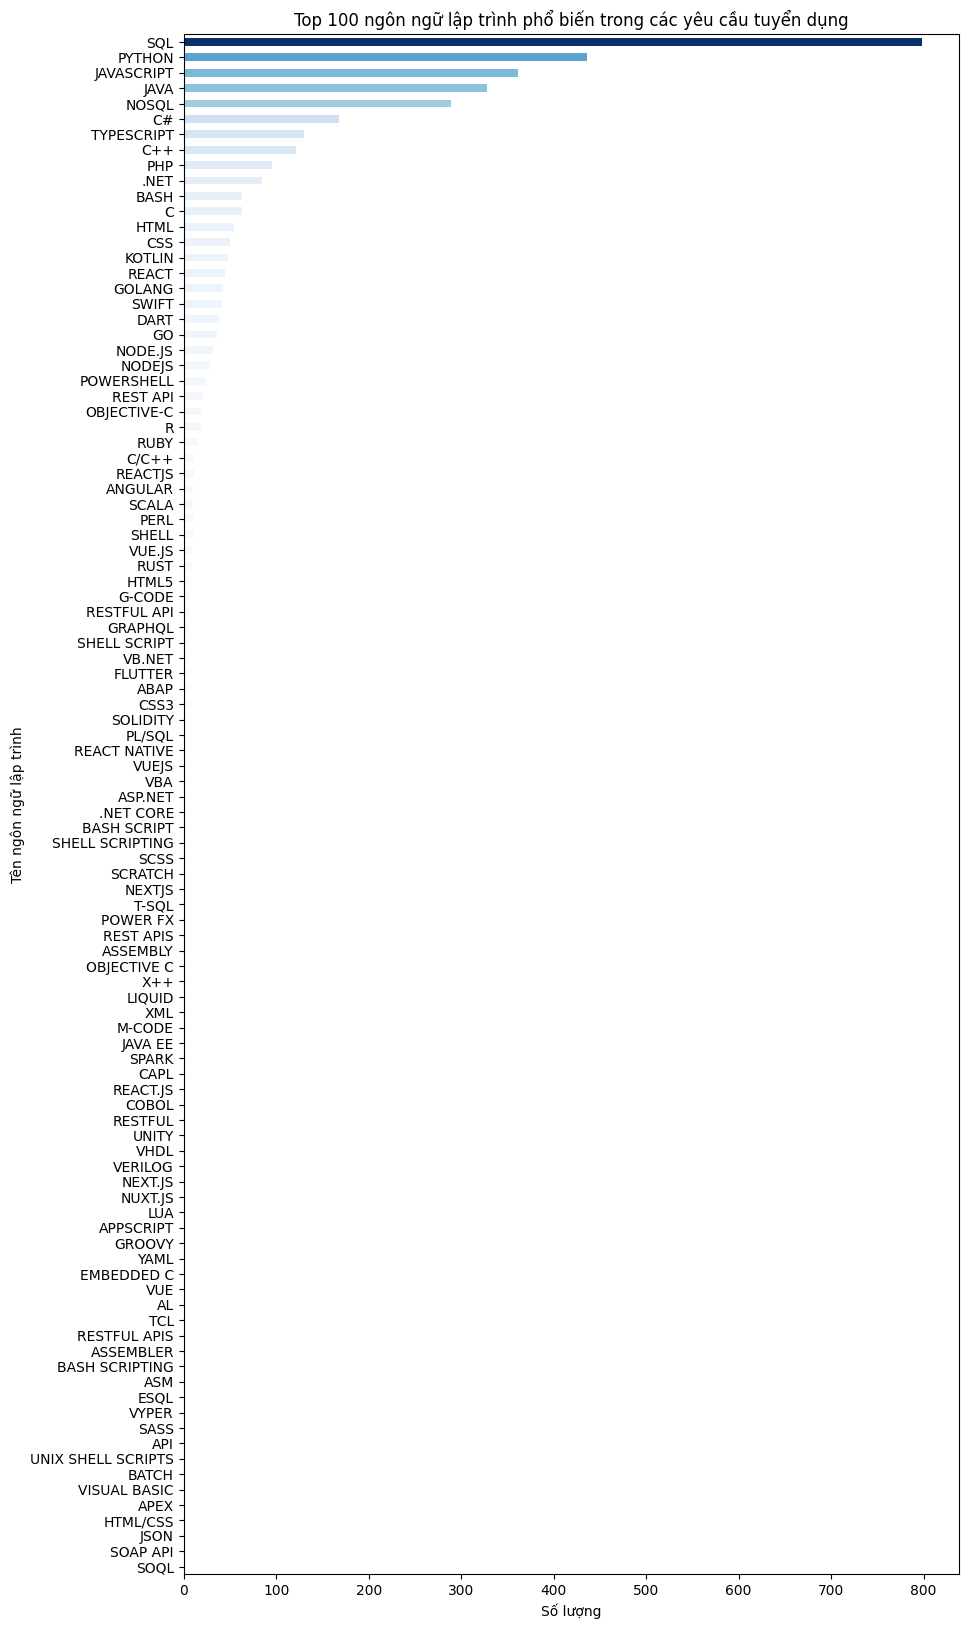

In [27]:
# Bước 1: Bỏ NaN
df_lang = df_final['Programming_Language'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=False)

# Lấy ra 100 Programming_Language phổ biến nhất
top_100_langs = lang_counts.nlargest(100).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 20))  # Điều chỉnh chiều cao để phù hợp với 100 mục

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(top_100_langs / top_100_langs.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
top_100_langs.plot(kind='barh', color=colors)
plt.ylabel('Tên ngôn ngữ lập trình')
plt.xlabel('Số lượng')
plt.title('Top 100 ngôn ngữ lập trình phổ biến trong các yêu cầu tuyển dụng')
plt.show()

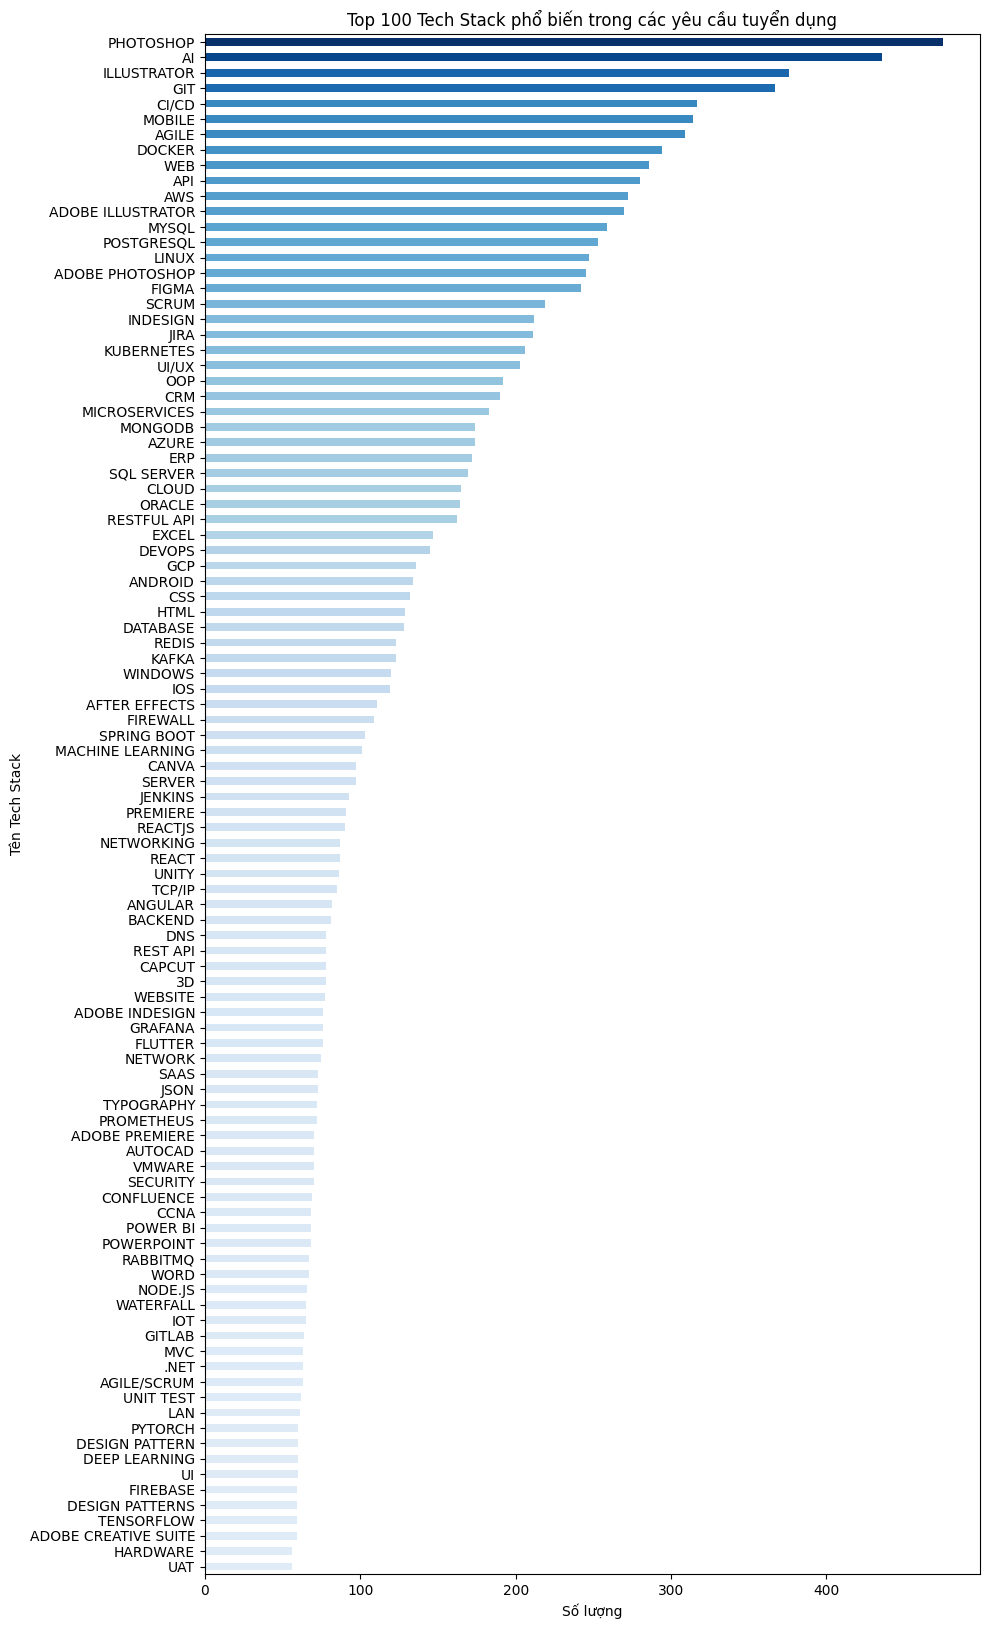

In [28]:
# Bước 1: Bỏ NaN
df_lang = df_final['Tech_Stack'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=False)

# Lấy ra 100 Tech Stack phổ biến nhất
top_100_langs = lang_counts.nlargest(100).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 20))  # Điều chỉnh chiều cao để phù hợp với 100 mục

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(top_100_langs / top_100_langs.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
top_100_langs.plot(kind='barh', color=colors)
plt.ylabel('Tên Tech Stack')
plt.xlabel('Số lượng')
plt.title('Top 100 Tech Stack phổ biến trong các yêu cầu tuyển dụng')
plt.show()

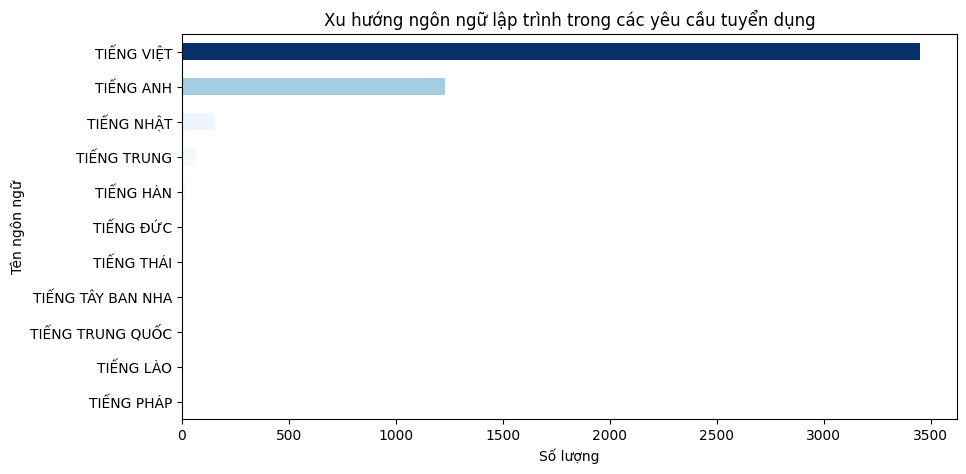

In [29]:
# Bước 1: Bỏ NaN
df_lang = df_final['Language'].dropna()

# Bước 2: Chuyển từ chuỗi dạng list → list thực (nếu cần)
df_lang = df_lang.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Bước 3: Gộp toàn bộ thành list lớn
all_langs = [lang for sublist in df_lang for lang in sublist]

# Bước 4: Đếm
lang_counts = pd.Series(Counter(all_langs)).sort_values(ascending=True)

# Bước 5: Vẽ biểu đồ với thang màu
plt.figure(figsize=(10, 5))

# Tạo thang màu dựa trên giá trị
colors = cm.Blues(lang_counts / lang_counts.max())  # Sử dụng thang màu 'Blues'

# Vẽ biểu đồ
lang_counts.plot(kind='barh', color=colors)
plt.ylabel('Tên ngôn ngữ')
plt.xlabel('Số lượng')
plt.title('Xu hướng ngôn ngữ lập trình trong các yêu cầu tuyển dụng')
plt.show()

# Kiểm tra lại bất thường trong dữ liệu ngày đi làm trong tuần 

In [30]:
df_extracted.head()

,Job_Title,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Tech_Stack,Programming_Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday
0,Kỹ Sư Triển Khai Dự Án Hệ Thống (Postsale System),"[CÔNG NGHỆ THÔNG TIN, IT INFRASTRUCTURE AND OPERATIONS, SYSTEM ENGINEER, VIỆC LÀM IT]",10,"[HÀ NỘI, HỒ CHÍ MINH]",[HÀ NỘI],500.0,1000.0,"[TIẾNG VIỆT, TIẾNG ANH]","[VMWARE, CITRIX, HYPER-V, HPE, IBM, DELL EMC, ACTIVE DIRECTORY, DNS, MAIL SERVER, PROXY, SAN, NAS, NETAPP, HP, FUJITSU, EMC, CLOUD, ORACLE, VMWARE CERTIFIED ASSOCIATE (VCA), MCSA, NETWORKING, WINDOWS SERVER, LINUX, UNIX, DHCP, DATABASE, BACKUP, MICROSOFT WORD, MICROSOFT EXCEL, MICROSOFT POWERPOINT]",[SQL],"[GIÁM SÁT THI CÔNG, QUẢN LÝ DỰ ÁN, VIẾT TÀI LIỆU KỸ THUẬT, TƯ VẤN GIẢI PHÁP, XỬ LÝ SỰ CỐ, QUẢN TRỊ HỆ THỐNG, BẢO TRÌ HỆ THỐNG, NGHIÊN CỨU SẢN PHẨM, ĐỌC HIỂU TÀI LIỆU KỸ THUẬT, GIAO TIẾP, GIẢI QUYẾT VẤN ĐỀ, TRIỂN KHAI PHẦN MỀM, KIẾN THỨC VỀ HỆ THỐNG, TRUNG THỰC, NĂNG ĐỘNG, NHIỆT TÌNH, CHỊU KHÓ, HÒA ĐỒNG, TINH THẦN TRÁCH NHIỆM]",45.0,20000000.0,40000000.0,2,6,False,False
1,Nhân Viên Tư Vấn Phát Triển Phần Mềm,"[KINH DOANH/BÁN HÀNG, MARKETING/PR/QUẢNG CÁO, SALES DỊCH VỤ QUẢNG CÁO/TRIỂN LÃM/SỰ KIỆN, MARKETING, SALES MARKETING]",8,[HỒ CHÍ MINH],[HỒ CHÍ MINH],1000.0,NaN,[TIẾNG VIỆT],"[WEBSITE, PHẦN MỀM BÁN HÀNG, PHẦN MỀM VĂN PHÒNG, PHẦN MỀM QUẢN LÝ TÀI LIỆU, HỆ THỐNG EMAIL, MẠNG LƯỚI, QUẢN LÝ WEBSITE]",None,"[TƯ VẤN KHÁCH HÀNG, KÝ KẾT HỢP ĐỒNG, XÂY DỰNG MỐI QUAN HỆ, CHĂM SÓC KHÁCH HÀNG, GIAO TIẾP, KINH DOANH PHẦN MỀM, KIẾN THỨC VỀ CÔNG NGHỆ THÔNG TIN, HIỂU BIẾT VỀ THỊ TRƯỜDNG CÔNG NGHỆ THÔNG TIN, AM HIỂU VỀ CÁC GIẢI PHÁP CÔNG NGHỆ THÔNG TIN]",49.0,10000000.0,25000000.0,2,6,True,False
2,Nhân Viên Kinh Doanh/Sale/Tư Vấn Bán Hàng (Máy In),"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES KỸ THUẬT (SALES ENGINEER), CÔNG NGHỆ THÔNG TIN KHÁC, BÁN HÀNG KỸ THUẬT IT, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,[TIẾNG VIỆT],[EXCEL],None,"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG LÀM VIỆC NHÓM, QUẢN TRỊ KINH DOANH, MARKETING]",NaN,8000000.0,12000000.0,<NA>,<NA>,False,False
3,Business Analyst,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, BUSINESS ANALYST (PHÂN TÍCH NGHIỆP VỤ), VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[CYBER SECURITY, DATA MODELING, MOCKUPS, PROTOTYPES, AGILE, UX/UI, DESIGN THINKING, TOÁN - TIN, KHOA HỌC MÁY TÍNH]",None,"[PHÂN TÍCH NGHIỆP VỤ, PHÂN TÍCH DỮ LIỆU, TƯ DUY LOGIC, KỸ NĂNG VIẾT, KỸ NĂNG TRÌNH BÀY, PHÂN TÍCH TRẢI NGHIỆM KHÁCH HÀNG, THIẾT KẾ HỆ THỐNG, GIAO TIẾP, PHỐI HỢP ĐA PHÒNG BAN, LÀM VIỆC NHÓM, CHỊU ĐƯỢC ÁP LỰC CAO, GIẢI QUYẾT VẤN ĐỀ, VIẾT TÀI LIỆU]",50.0,25000000.0,30000000.0,2,6,False,False
4,Nhân Viên Kinh Doanh Phần Mềm Erp/ Sales Erp,"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES IT PHẦN MỀM, KINH DOANH PHẦN MỀM, VIỆC LÀM IT]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,"[TIẾNG VIỆT, TIẾNG TRUNG, TIẾNG ANH]","[ERP, CRM]",None,"[XÂY DỰNG MỐI QUAN HỆ, GIAO TIẾP, PHÂN TÍCH NGHIỆP VỤ, THUYẾT TRÌNH, ĐÀM PHÁN KINH DOANH, CHỊU ĐƯỢC ÁP LỰC, KHẢ NĂNG HỌC HỎI NHANH]",45.0,30000000.0,60000000.0,2,6,False,False


In [31]:
test = pd.read_parquet(r'D:\Python_code\DS111_Final_Term_Project\DS111\analysis-job-trend\data\2-API-processing\API_data_raw.parquet')
check = pd.DataFrame(columns=test.columns)  # Tạo DataFrame rỗng với các cột là các trường trong class Recruiment_Info


In [32]:
data_test = test.copy()
data_original_test = data_original.copy()

In [33]:
data_original['tags_role'].unique

<bound method Series.unique of 0                                                              Công nghệ Thông tin, IT Infrastructure and Operations, System Engineer, Việc làm IT
1       Kinh doanh/Bán hàng, Marketing/PR/Quảng cáo, Marketing/PR/Quảng cáo, Sales dịch vụ Quảng cáo/Triển lãm/Sự kiện, Marketing, Sales Marketing
2           Kinh doanh/Bán hàng, Công nghệ Thông tin, Sales Kỹ thuật (Sales Engineer), Công nghệ thông tin khác, Bán hàng kỹ thuật IT, Việc làm IT
3                                                     Công nghệ Thông tin, Product Management, Business Analyst (Phân tích nghiệp vụ), Việc làm IT
4                                                    Kinh doanh/Bán hàng, Công nghệ Thông tin, Sales IT Phần mềm, Kinh doanh phần mềm, Việc làm IT
                                                                           ...                                                                    
3453                                                 Kinh doanh/Bán hàng, Công nghệ Thô

In [34]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  3458 non-null   object 
 1   Roles                      3455 non-null   object 
 2   Recruitment_Count          3458 non-null   Int64  
 3   Province                   3456 non-null   object 
 4   Company_Location           3456 non-null   object 
 5   Current_Employee_Min       3299 non-null   float64
 6   Current_Employee_Max       2914 non-null   float64
 7   Language                   3456 non-null   object 
 8   Tech_Stack                 3274 non-null   object 
 9   Programming_Language       1326 non-null   object 
 10  Skills                     3435 non-null   object 
 11  Total_Work_Hour            2948 non-null   float64
 12  Salary_Min                 1829 non-null   float64
 13  Salary_Max                 2092 non-null   float

In [35]:
#Hiển thị max số lượng cột 
pd.set_option('display.max_columns', None)

In [36]:
test.head(10)

,Job_Title,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Tech_Stack,Programming_Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Experience_Years,Deadline,Company_Name,Company_Industry,Job_Level,Academic_Level,Job_Type,Company_URL,Job_URL,Date_Crawl,Layout_Type
0,Kỹ Sư Triển Khai Dự Án Hệ Thống (Postsale System),"[CÔNG NGHỆ THÔNG TIN, IT INFRASTRUCTURE AND OPERATIONS, SYSTEM ENGINEER, VIỆC LÀM IT]",10,"[HÀ NỘI, HỒ CHÍ MINH]",[HÀ NỘI],500.0,1000.0,"[TIẾNG VIỆT, TIẾNG ANH]","[VMWARE, CITRIX, HYPER-V, HPE, IBM, DELL EMC, ACTIVE DIRECTORY, DNS, MAIL SERVER, PROXY, SAN, NAS, NETAPP, HP, FUJITSU, EMC, CLOUD, ORACLE, VMWARE CERTIFIED ASSOCIATE (VCA), MCSA, NETWORKING, WINDOWS SERVER, LINUX, UNIX, DHCP, DATABASE, BACKUP, MICROSOFT WORD, MICROSOFT EXCEL, MICROSOFT POWERPOINT]",[SQL],"[GIÁM SÁT THI CÔNG, QUẢN LÝ DỰ ÁN, VIẾT TÀI LIỆU KỸ THUẬT, TƯ VẤN GIẢI PHÁP, XỬ LÝ SỰ CỐ, QUẢN TRỊ HỆ THỐNG, BẢO TRÌ HỆ THỐNG, NGHIÊN CỨU SẢN PHẨM, ĐỌC HIỂU TÀI LIỆU KỸ THUẬT, GIAO TIẾP, GIẢI QUYẾT VẤN ĐỀ, TRIỂN KHAI PHẦN MỀM, KIẾN THỨC VỀ HỆ THỐNG, TRUNG THỰC, NĂNG ĐỘNG, NHIỆT TÌNH, CHỊU KHÓ, HÒA ĐỒNG, TINH THẦN TRÁCH NHIỆM]",45.0,20000000.0,40000000.0,2,6,0.0,0.0,2 năm,31/01/2026,Công ty Cổ phần Hệ thống Công nghệ ETC,IT - Phần mềm,Nhân viên,Cao Đẳng trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-co-phan-he-thong-cong-nghe-etc/200939.html,https://www.topcv.vn/viec-lam/ky-su-trien-khai-du-an-he-thong-postsale-system-thu-nhap-upto-40tr/1949543.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:17,standard
1,Nhân Viên Tư Vấn Phát Triển Phần Mềm,"[KINH DOANH/BÁN HÀNG, MARKETING/PR/QUẢNG CÁO, SALES DỊCH VỤ QUẢNG CÁO/TRIỂN LÃM/SỰ KIỆN, MARKETING, SALES MARKETING]",8,[HỒ CHÍ MINH],[HỒ CHÍ MINH],1000.0,NaN,[TIẾNG VIỆT],"[WEBSITE, PHẦN MỀM BÁN HÀNG, PHẦN MỀM VĂN PHÒNG, PHẦN MỀM QUẢN LÝ TÀI LIỆU, HỆ THỐNG EMAIL, MẠNG LƯỚI, QUẢN LÝ WEBSITE]",None,"[TƯ VẤN KHÁCH HÀNG, KÝ KẾT HỢP ĐỒNG, XÂY DỰNG MỐI QUAN HỆ, CHĂM SÓC KHÁCH HÀNG, GIAO TIẾP, KINH DOANH PHẦN MỀM, KIẾN THỨC VỀ CÔNG NGHỆ THÔNG TIN, HIỂU BIẾT VỀ THỊ TRƯỜDNG CÔNG NGHỆ THÔNG TIN, AM HIỂU VỀ CÁC GIẢI PHÁP CÔNG NGHỆ THÔNG TIN]",49.0,10000000.0,25000000.0,2,6,1.0,0.0,Không yêu cầu,02/01/2026,CÔNG TY TNHH CÔNG NGHỆ PHẦN MỀM NASANI,Internet / Online,Nhân viên,Trung cấp trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-tnhh-cong-nghe-phan-mem-nasani/233549.html,https://www.topcv.vn/viec-lam/nhan-vien-tu-van-phat-trien-phan-mem-hcm-thu-nhap-len-den-25tr-thang/1971777.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:28,standard
2,Nhân Viên Kinh Doanh/Sale/Tư Vấn Bán Hàng (Máy In),"[KINH DOANH/BÁN HÀNG, CÔNG NGHỆ THÔNG TIN, SALES KỸ THUẬT (SALES ENGINEER), CÔNG NGHỆ THÔNG TIN KHÁC, BÁN HÀNG KỸ THUẬT IT, VIỆC LÀM IT]",2,[HỒ CHÍ MINH],[HỒ CHÍ MINH],25.0,99.0,[TIẾNG VIỆT],[EXCEL],None,"[KỸ NĂNG GIAO TIẾP, KỸ NĂNG LÀM VIỆC NHÓM, QUẢN TRỊ KINH DOANH, MARKETING]",NaN,8000000.0,12000000.0,<NA>,<NA>,0.0,0.0,Dưới 1 năm,02/01/2026,CÔNG TY CP THIẾT BỊ CÔNG NGHIỆP HUỲNH LONG,Cơ khí,Nhân viên,Trung cấp trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-cp-thiet-bi-cong-nghiep-huynh-long/105523.html,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-sale-tu-van-ban-hangmay-inluong-cung-12tr-hoa-hong-nhan-viec-ngay/1971328.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:13:41,standard
3,Business Analyst,"[CÔNG NGHỆ THÔNG TIN, PRODUCT MANAGEMENT, BUSINESS ANALYST (PHÂN TÍCH NGHIỆP VỤ), VIỆC LÀM IT]",1,[HÀ NỘI],[HÀ NỘI],25.0,99.0,"[TIẾNG VIỆT, TIẾNG ANH]","[CYBER SECURITY, DATA MODELING, MOCKUPS, PROTOTYPES, AGILE, UX/UI, DESIGN THINKING, TOÁN - TIN, KHOA HỌC MÁY TÍNH]",None,"[PHÂN TÍCH NGHIỆP VỤ, PHÂN TÍCH DỮ LIỆU, TƯ DUY LOGIC, KỸ NĂNG VIẾT, KỸ NĂNG TRÌNH BÀY, PHÂN

In [37]:
test[['Total_Work_Hour', 'Job_URL']].head(100)

,Total_Work_Hour,Job_URL
0,45.00,https://www.topcv.vn/viec-lam/ky-su-trien-khai-du-an-he-thong-postsale-system-thu-nhap-upto-40tr/1949543.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
1,49.00,https://www.topcv.vn/viec-lam/nhan-vien-tu-van-phat-trien-phan-mem-hcm-thu-nhap-len-den-25tr-thang/1971777.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
2,NaN,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-sale-tu-van-ban-hangmay-inluong-cung-12tr-hoa-hong-nhan-viec-ngay/1971328.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
3,50.00,https://www.topcv.vn/viec-lam/business-analyst-tu-3-nam-kinh-nghiem-thu-nhap-upto-30m-tai-ha-noi/1966948.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
4,45.00,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-phan-mem-erp-sales-erp-thu-nhap-cao-upto-30-60-trieu-nhan-viec-ngay-tai-quan-7/1891406.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
5,45.00,https://www.topcv.vn/viec-lam/ai-robotics-engineer/1974897.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
6,54.00,https://www.topcv.vn/viec-lam/network-engineer-trien-khai/1975191.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
7,45.00,https://www.topcv.vn/viec-lam/intern-qc-japanese-n4/1967453.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
8,NaN,https://www.topcv.vn/viec-lam/product-manager/1969894.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
9,49.00,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-cntt/1973321.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807


## Kiểm tra miền giá trị của các thuộc tính ngày đi làm trong tuần


In [38]:
unique_first_working_days = test['First_Working_Day_Of_Week'].unique().tolist()
unique_last_working_days = test['Last_Working_Day_Of_Week'].unique().tolist()

print("Unique values of First_Working_Day_Of_Week:", unique_first_working_days)
print("Unique values of Last_Working_Day_Of_Week:", unique_last_working_days)

Unique values of First_Working_Day_Of_Week: [2, <NA>, 3]
Unique values of Last_Working_Day_Of_Week: [6, <NA>, 4]


In [39]:
#Kiểm tra các mẫu bất thường về ngày đi làm trong tuần
# test = df_extracted.copy() # Tạo bản sao của DataFrame đã trích xuất thông tin
# check = pd.DataFrame(columns=test.columns)  
# Kiểm tra nếu 'job_title' chứa một trong hai từ khóa "Triệu" hoặc "lương"
for i in range(len(test)):
    # if pd.notna(test.iloc[i]['job_title']) and any(keyword in test.iloc[i]['job_title'] for keyword in ['Triệu', 'Lương', 'Tiếng']):
    #     print(f"Row {i} contains 'Triệu' or 'Lương' in 'job_title':")
    if (pd.isna(test.iloc[i]['First_Working_Day_Of_Week']) and pd.notna(test.iloc[i]['Last_Working_Day_Of_Week'])) or (
        pd.notna(test.iloc[i]['First_Working_Day_Of_Week']) and (test.iloc[i]['First_Working_Day_Of_Week'] != 2)) or (
        (pd.notna(test.iloc[i]['First_Working_Day_Of_Week']) and pd.isna(test.iloc[i]['Last_Working_Day_Of_Week']))) or(
            pd.notna(test.iloc[i]['Last_Working_Day_Of_Week']) and (test.iloc[i]['Last_Working_Day_Of_Week'] != 6) or (
                test.iloc[i]['Work_On_Sunday'] == 1)
        ):
        check.loc[len(check)] = test.iloc[i]


## Các mẫu bất thường về thời gian làm việc trong tuần trong dữ liệu 

In [40]:
test[test['Work_On_Saturday']==1][['First_Working_Day_Of_Week','Last_Working_Day_Of_Week','Work_On_Saturday','Work_On_Sunday', 'Job_URL']].head(200)

,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Job_URL
1,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/nhan-vien-tu-van-phat-trien-phan-mem-hcm-thu-nhap-len-den-25tr-thang/1971777.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
6,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/network-engineer-trien-khai/1975191.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
9,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/nhan-vien-kinh-doanh-cntt/1973321.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
10,<NA>,<NA>,1.0,1.0,https://www.topcv.vn/viec-lam/nhan-vien-gan-nhan-kiem-duyet-noi-dung-san-thuong-mai-dien-tu-mang-cham-soc-khach-hang-thu-nhap-8-trieu-thang-quan-12-di-lam-ngay/1968880.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
16,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/pm-du-an-quan-ly-du-an-35-50-trieu-thuong-du-an-ha-noi-tphcm/1969916.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
17,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/chuyen-vien-cong-nghe-thong-tin-chuyen-doi-so-thu-nhap-15-20-trieu-tai-bac-ninh/1964069.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
19,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/lap-trinh-vien-net/1972238.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
21,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/chuyen-vien-kiem-tra-chat-luong-phan-mem-tester/1202799.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
27,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/frontend-reactjs-nextjs-developer-tu-2-5-nam-kinh-nghiem-thu-nhap-15-25-trieu-tai-ha-noi/1944459.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807
33,2,6,1.0,0.0,https://www.topcv.vn/viec-lam/net-developer/1907652.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807


In [41]:
# Kiểm tra có bao nhiêu cột Work_On_Sunday = 1
test[test['Work_On_Saturday']==1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1310 entries, 1 to 3457
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_Title                  1310 non-null   object 
 1   Roles                      1310 non-null   object 
 2   Recruitment_Count          1310 non-null   Int64  
 3   Province                   1310 non-null   object 
 4   Company_Location           1310 non-null   object 
 5   Current_Employee_Min       1254 non-null   float64
 6   Current_Employee_Max       1133 non-null   float64
 7   Language                   1310 non-null   object 
 8   Tech_Stack                 1221 non-null   object 
 9   Programming_Language       315 non-null    object 
 10  Skills                     1306 non-null   object 
 11  Total_Work_Hour            1112 non-null   float64
 12  Salary_Min                 915 non-null    float64
 13  Salary_Max                 959 non-null    float64
 1

In [42]:
check

,Job_Title,Roles,Recruitment_Count,Province,Company_Location,Current_Employee_Min,Current_Employee_Max,Language,Tech_Stack,Programming_Language,Skills,Total_Work_Hour,Salary_Min,Salary_Max,First_Working_Day_Of_Week,Last_Working_Day_Of_Week,Work_On_Saturday,Work_On_Sunday,Experience_Years,Deadline,Company_Name,Company_Industry,Job_Level,Academic_Level,Job_Type,Company_URL,Job_URL,Date_Crawl,Layout_Type
0,Nhân Viên Gán Nhãn & Kiểm Duyệt Nội Dung Sàn Thương Mại Điện Tử (Mảng Chăm Sóc Khách Hàng),"[CHĂM SÓC KHÁCH HÀNG (CUSTOMER SERVICE), VẬN HÀNH, CÔNG NGHỆ THÔNG TIN, BUSINESS OPERATION (VẬN HÀNH KINH DOANH), ARTIFICIAL INTELLIGENCE (AI), DATA LABELING (GÁN NHÃN DỮ LIỆU), VIỆC LÀM IT]",10,[HỒ CHÍ MINH],[HỒ CHÍ MINH],10.0,24.0,"[TIẾNG VIỆT, TIẾNG ANH]","[DATA LABELING, ARTIFICIAL INTELLIGENCE]",None,"[TIẾNG ANH, TỐC ĐỘ ĐÁNH MÁY, KỸ NĂNG GIAO TIẾP, KỸ NĂNG XỬ LÝ TÌNH HUỐNG, CHĂM SÓC KHÁCH HÀNG, SỬ DỤNG MÁY TÍNH, PHÂN TÍCH THÔNG TIN]",37.5,7400000.0,8000000.0,NaN,NaN,1.0,1.0,Không yêu cầu,31/12/2025,CÔNG TY TNHH NGUYỄN AN NAM,Tư vấn,Nhân viên,Trung học phổ thông (Cấp 3) trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/cong-ty-tnhh-nguyen-an-nam/207649.html,https://www.topcv.vn/viec-lam/nhan-vien-gan-nhan-kiem-duyet-noi-dung-san-thuong-mai-dien-tu-mang-cham-soc-khach-hang-thu-nhap-8-trieu-thang-quan-12-di-lam-ngay/1968880.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807,09/12/2025 13:15:19,standard
1,Giáo Viên Lập Trình - Thủ Dầu Một (Bình Dương),"[GIÁO DỤC/ĐÀO TẠO, GIÁO VIÊN/GIẢNG VIÊN/GIA SƯ, GIÁO VIÊN TIN HỌC]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[ROBOTICS, UNITY, MINECRAFT MODDING, SCRATCH, ROBLOX SCRIPTING, PHẦN MỀM GIÁO DỤC]","[PYTHON, C++]","[KỸ NĂNG GIAO TIẾP, THUYẾT TRÌNH, NGHIÊN CỨU, GIẢNG DẠY LẬP TRÌNH, SƯ PHẠM, KIÊN NHẪN, TRUYỀN ĐẠT KIẾN THỨC]",28.0,NaN,NaN,NaN,NaN,1.0,1.0,1 năm,26/12/2025,Wall Street English,Giáo dục / Đào tạo,Nhân viên,Đại Học trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/wall-street-english/62.html,https://www.topcv.vn/viec-lam/giao-vien-lap-trinh-thu-dau-mot-binh-duong/1900207.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820,09/12/2025 13:34:31,standard
2,Trưởng Nhóm Học Thuật Về Lập Trình/ Coding Academic Leader,"[GIÁO DỤC/ĐÀO TẠO, QUẢN LÝ GIÁO DỤC, QUẢN LÝ CHẤT LƯỢNG GIÁO DỤC]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[UNITY, MINECRAFT MODDING, SCRATCH, ROBLOX SCRIPTING, ROBOTICS]","[PYTHON, C++]","[KỸ NĂNG GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG NGHIÊN CỨU, KỸ NĂNG SƯ PHẠM, GIẢNG DẠY LẬP TRÌNH, QUẢN LÝ LỚP HỌC, KIẾN THỨC VỀ LẬP TRÌNH VÀ KHOA HỌC MÁY TÍNH]",48.0,12000000.0,13000000.0,2,6,1.0,1.0,2 năm,14/12/2025,Wall Street English,Giáo dục / Đào tạo,Trưởng nhóm,Đại Học trở lên,Toàn thời gian,https://www.topcv.vn/cong-ty/wall-street-english/62.html,https://www.topcv.vn/viec-lam/truong-nhom-hoc-thuat-ve-lap-trinh-coding-academic-leader-quan-9/1952097.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820,09/12/2025 13:36:08,standard
3,Giáo Viên Lập Trình - Part-time,"[GIÁO DỤC/ĐÀO TẠO, VĂN HOÁ/NGHỆ THUẬT/KHOA HỌC, GIÁO VIÊN STEAM/STEM]",1,[HỒ CHÍ MINH],[HỒ CHÍ MINH],100.0,499.0,[TIẾNG VIỆT],"[UNITY, MINECRAFT MODDING, SCRATCH, ROBLOX SCRIPTING, ROBOTICS]","[PYTHON, C++]","[KỸ NĂNG GIAO TIẾP, KỸ NĂNG THUYẾT TRÌNH, KỸ NĂNG NGHIÊN CỨU, KINH NGHIỆM GIẢNG DẠY, KIẾN THỨC VỀ LẬP TRÌNH, KỸ NĂNG SƯ PHẠM, KỸ NĂNG QUẢN LÝ LỚP HỌC, KỸ NĂNG SỬ DỤNG CÔNG CỤ DẠY HỌC TRỰC TUYẾN]",NaN,NaN,NaN,2,6,1.0,1.0,Dưới 1 năm,25/12/2025,Wall Street English,Giáo dục / Đào tạo,Nhân viên,Đại Học trở lên,Bán thời gian,https://www.topcv.vn/cong-ty/wall-street-english/62.html,https://www.topcv.vn/viec-lam/giao-vien-lap-trinh-part-time-binh-duong/1963316.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095842,09/12/2025 13:57:12,standard
4,Hỗ Trợ Kỹ Thuật - Trực Ca,"[IT SUPPORT SPECIALIST, VIỆC LÀM IT]",

## Đường link dẫn tới các thông tin tuyển dụng trong mục kiểm tra bất thường trong dữ liệu (biến check) 

In [43]:
list_bad_url = check['Job_URL'].tolist() # Lấy danh sách các URL từ DataFrame
list_bad_url

['https://www.topcv.vn/viec-lam/nhan-vien-gan-nhan-kiem-duyet-noi-dung-san-thuong-mai-dien-tu-mang-cham-soc-khach-hang-thu-nhap-8-trieu-thang-quan-12-di-lam-ngay/1968880.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095807',
 'https://www.topcv.vn/viec-lam/giao-vien-lap-trinh-thu-dau-mot-binh-duong/1900207.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820',
 'https://www.topcv.vn/viec-lam/truong-nhom-hoc-thuat-ve-lap-trinh-coding-academic-leader-quan-9/1952097.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095820',
 'https://www.topcv.vn/viec-lam/giao-vien-lap-trinh-part-time-binh-duong/1963316.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_1765095842',
 'https://www.topcv.vn/viec-lam/ho-tro-ky-thuat-truc-ca/1697469.html?ta_source=JobSearchList_LinkDetail&u_sr_id=vhbFIo4GqaZLKyp8jn9Cn4VEepc9rh4hVUZWiqL6_